## Penguins

<img src= https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguin.png width=600 >


#### Columns in the dataset
- species: penguin species (Chinstrap, Adélie, or Gentoo)
- island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)
- bill_length_mm: bill length (mm)
- bill_length_mm: bill depth (mm)
- flipper_length_mm: flipper length (mm)
- body_mass_g: body mass (g)
- Sex: penguin sex

<img src= https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguin2.png width=600 >


In [25]:
!wget https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv

--2024-12-04 09:47:10--  https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv
Resolving frenzy86.s3.eu-west-2.amazonaws.com (frenzy86.s3.eu-west-2.amazonaws.com)... 52.95.144.18, 3.5.245.174, 52.95.144.42, ...
Connecting to frenzy86.s3.eu-west-2.amazonaws.com (frenzy86.s3.eu-west-2.amazonaws.com)|52.95.144.18|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15134 (15K) [text/csv]
Saving to: ‘penguins.csv.3’

penguins.csv.3      100%[===================>]  14,78K  --.-KB/s    in 0s      

2024-12-04 09:47:10 (253 MB/s) - ‘penguins.csv.3’ saved [15134/15134]



In [26]:
path = "https://frenzy86.s3.eu-west-2.amazonaws.com/python/penguins.csv"

In [27]:
import pandas as pd

df=pd.read_csv(path)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,male
1,Adelie,Torgersen,39.5,17.4,186,3800,female
2,Adelie,Torgersen,40.3,18.0,195,3250,female
3,Adelie,Torgersen,36.7,19.3,193,3450,female
4,Adelie,Torgersen,39.3,20.6,190,3650,male
...,...,...,...,...,...,...,...
328,Chinstrap,Dream,55.8,19.8,207,4000,male
329,Chinstrap,Dream,43.5,18.1,202,3400,female
330,Chinstrap,Dream,49.6,18.2,193,3775,male
331,Chinstrap,Dream,50.8,19.0,210,4100,male


In [ ]:
df.columns


In [29]:
df['species'].value_counts()

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

In [30]:
df['island'].value_counts()

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

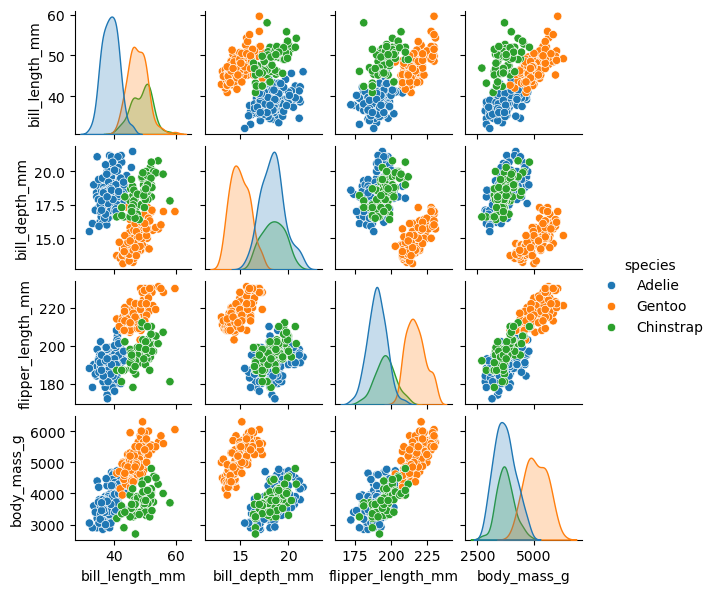

In [31]:
import seaborn as sns
sns.pairplot(df, hue='species',height=1.5)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier()

In [33]:
df_agg=df[['species','island']]

In [34]:
import numpy as np
agg=df_agg.groupby(['island','species'])
agg.aggregate(np.sum)

/tmp/ipykernel_16495/82212390.py:3: FutureWarning: The provided callable <function sum at 0x7a244afc39c0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  agg.aggregate(np.sum)


Empty DataFrame
Columns: []
Index: [(Biscoe, Adelie), (Biscoe, Gentoo), (Dream, Adelie), (Dream, Chinstrap), (Torgersen, Adelie)]

<AxesSubplot: xlabel='island', ylabel='count'>

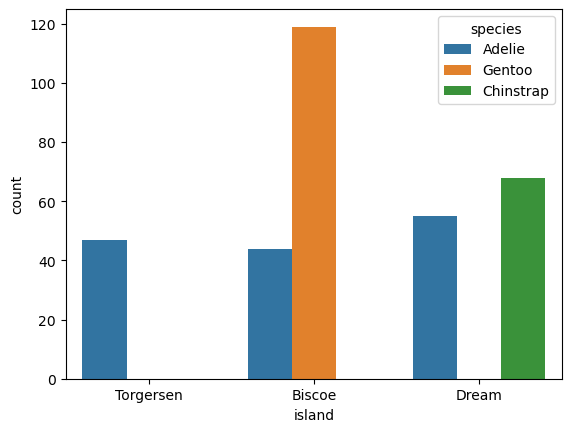

In [35]:
sns.countplot(x='island',data=df_agg,hue='species')

In [36]:
island={'Biscoe':0,'Dream':1,'Torgensen':2}
sex={'male':0,'female':1}
df['island']=df['island'].map(island)
df['sex']=df['sex'].map(sex)

In [37]:
from sklearn.model_selection import train_test_split
X=df[['island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g']]
y=df[['species']]

X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,train_size=0.75,random_state=69)

In [38]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [39]:
model.score(X_test,y_test)

1.0

In [40]:
from sklearn.model_selection import cross_val_score

cross_val_score(model,X,y,cv=5)

/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/lib/python3/dist-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(esti

array([1.        , 0.98507463, 0.98507463, 1.        , 0.96969697])

In [72]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca=PCA(2)

X=X.dropna()

scaled_X=pca.fit_transform(X)

scaled_X = StandardScaler().fit_transform(scaled_X)

scaled_X=pd.DataFrame(scaled_X)

scaled_X

,0,1
0,-1.084537,2.158708
1,-0.840559,1.812383
2,-0.596533,1.143038
3,-0.413696,1.895892
4,-0.596686,2.191869
...,...,...
281,-0.352242,-1.706965
282,-1.083987,-1.842291
283,-0.626879,-0.076865
284,-0.230273,-1.668636


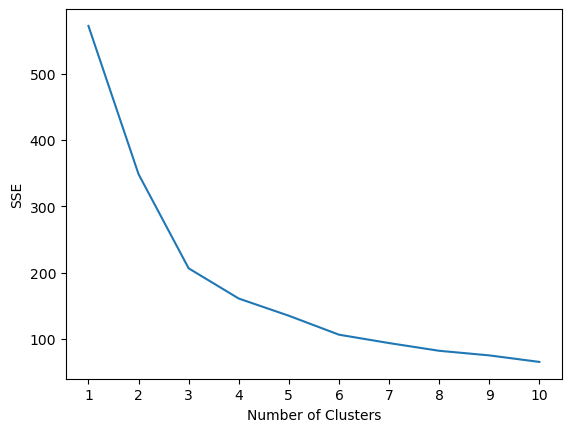

In [73]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_X)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [74]:
kmeans=KMeans(n_clusters=3)

labels=kmeans.fit_predict(X)
labels

array([2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 2, 0,
       2, 2, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 0,
       2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 0, 2],
      dtype=int32)

In [75]:
scaled_X['label']=labels
scaled_X

,0,1,label
0,-1.084537,2.158708,2
1,-0.840559,1.812383,2
2,-0.596533,1.143038,2
3,-0.413696,1.895892,0
4,-0.596686,2.191869,2
...,...,...,...
281,-0.352242,-1.706965,0
282,-1.083987,-1.842291,2
283,-0.626879,-0.076865,2
284,-0.230273,-1.668636,0


In [83]:
lable_filtered0=scaled_X.loc[scaled_X['label'] == 0]
lable_filtered0

,0,1,label
3,-0.413696,1.895892,0
9,-0.413781,2.469425,0
11,-0.474799,2.764986,0
13,-0.474671,1.805418,0
15,-0.169623,0.861359,0
...,...,...,...
271,-0.291373,-0.831854,0
275,-0.291380,-0.766378,0
278,-0.413244,-1.512365,0
281,-0.352242,-1.706965,0


In [84]:
lable_filtered1=scaled_X.loc[scaled_X['label'] == 1]
lable_filtered1

,0,1,label
100,1.721034,-0.765904,1
102,1.720811,0.825019,1
103,1.354946,0.656660,1
106,1.111149,-0.274404,1
108,1.050108,0.145161,1
...,...,...,...
213,0.775743,-0.260500,1
214,0.684309,-0.536570,1
215,1.781854,0.389777,1
216,1.111012,0.722954,1


In [85]:
lable_filtered2=scaled_X.loc[scaled_X['label'] == 2]
lable_filtered2

,0,1,label
0,-1.084537,2.158708,2
1,-0.840559,1.812383,2
2,-0.596533,1.143038,2
4,-0.596686,2.191869,2
5,-0.596572,1.433930,2
...,...,...,...
279,-0.779381,0.285530,2
280,-0.779274,-0.460864,2
282,-1.083987,-1.842291,2
283,-0.626879,-0.076865,2


In [89]:
lable_filtered0.columns

Index([0, 1, 'label'], dtype='object')

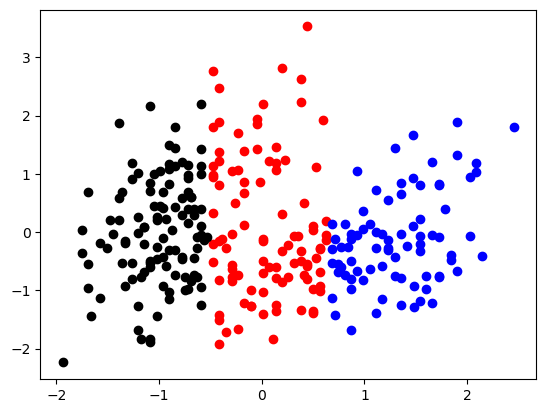

In [92]:
plt.scatter(x=lable_filtered0[0],y=lable_filtered0[1],c='red')
plt.scatter(x=lable_filtered1[0],y=lable_filtered1[1],c='blue')
plt.scatter(x=lable_filtered2[0],y=lable_filtered2[1],c='black')
plt.show()